Goal

By the end of this notebook, you should answer:

How many customers churn?
Who churns?
Why do they churn?
Which features affect churn?
What business actions should the company take?

Section 1 — Import Libraries

In [119]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Section 2 — Load Dataset

In [120]:
df = pd.read_csv("../data/raw/churn.csv")

df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


Section 3 — Dataset Overview

In [121]:
print("="*50)
print("Dataset Shape")
print("="*50)

print(df.shape)

Dataset Shape
(3150, 14)


In [122]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)
memory usa

In [123]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Call Failure,3150.0,7.627937,7.263886,0.0,1.00000,6.00,12.00000,36.00
Complains,3150.0,0.076508,0.265851,0.0,0.00000,0.00,0.00000,1.00
Subscription Length,3150.0,32.541905,8.573482,3.0,30.00000,35.00,38.00000,47.00
Charge Amount,3150.0,0.942857,1.521072,0.0,0.00000,0.00,1.00000,10.00
Seconds of Use,3150.0,4472.459683,4197.908687,0.0,1391.25000,2990.00,6478.25000,17090.00
Frequency of use,3150.0,69.460635,57.413308,0.0,27.00000,54.00,95.00000,255.00
Frequency of SMS,3150.0,73.174921,112.237560,0.0,6.00000,21.00,87.00000,522.00
Distinct Called Numbers,3150.0,23.509841,17.217337,0.0,10.00000,21.00,34.00000,97.00
Age Group,3150.0,2.826032,0.892555,1.0,2.00000,3.00,3.00000,5.00
Tariff Plan,3150.0,1.077778,0.267864,1.0,1.00000,1.00,1.00000,2.00


Section 4 — Data Quality Check

In [125]:
# Missing Values

missing = df.isnull().sum()

missing

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [126]:
# Duplicates

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 300


In [127]:
# Unique Values

unique = pd.DataFrame({
    "Unique Values":df.nunique()
})

unique

,Unique Values
Call Failure,37
Complains,2
Subscription Length,45
Charge Amount,11
Seconds of Use,1756
Frequency of use,242
Frequency of SMS,405
Distinct Called Numbers,92
Age Group,5
Tariff Plan,2


Section 5 — Target Variable Analysis

In [129]:
# Customer Churn Distribution

churn_counts = df["Churn"].value_counts().sort_index()

churn_percent = round(
    df["Churn"].value_counts(normalize=True)*100,
    2
)

print(churn_counts)

print(churn_percent)

Churn
0    2655
1     495
Name: count, dtype: int64
Churn
0    84.29
1    15.71
Name: proportion, dtype: float64


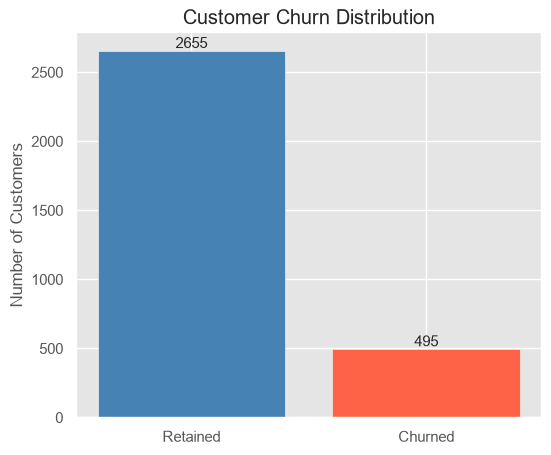

In [131]:
# Visualization

plt.figure(figsize=(6,5))

bars = plt.bar(
    ["Retained","Churned"],
    churn_counts,
    color=["steelblue","tomato"]
)

plt.title("Customer Churn Distribution")

plt.ylabel("Number of Customers")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+20,
        int(bar.get_height()),
        ha="center",
        fontsize=11
    )

plt.show()

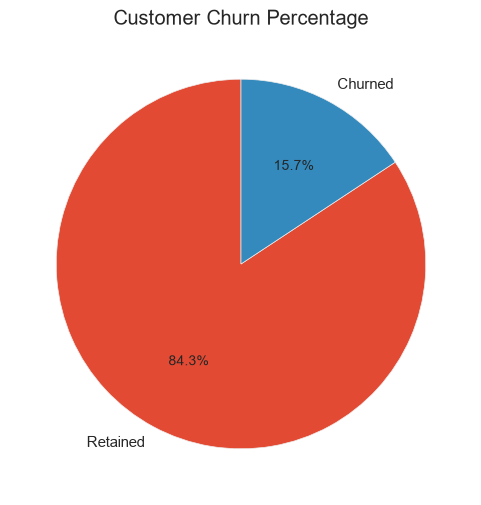

In [133]:
# Pie Chart

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=["Retained","Churned"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.show()

### Business Insight

• Dataset contains **3150 customers**.

• **15.71%** customers have churned.

• **84.29%** customers remain active.

• Although the churn percentage is relatively low, customer acquisition costs are generally much higher than retention costs. Identifying high-risk customers can improve profitability.

Section 6 — Univariate Analysis

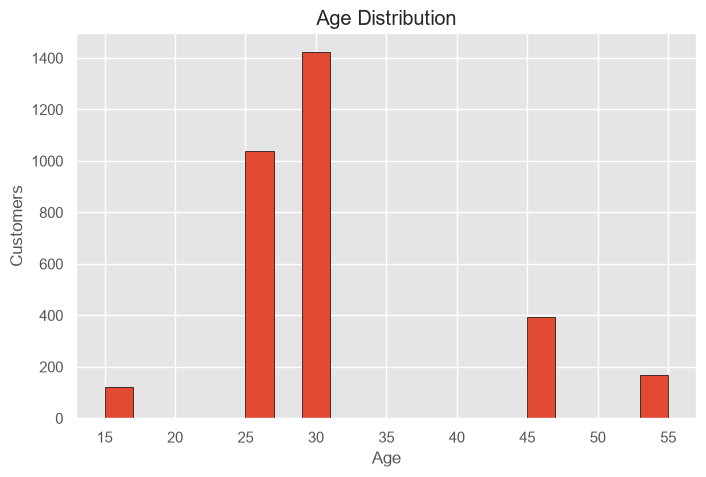

In [135]:
# Age

plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=20,
    edgecolor="black"
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Customers")

plt.show()

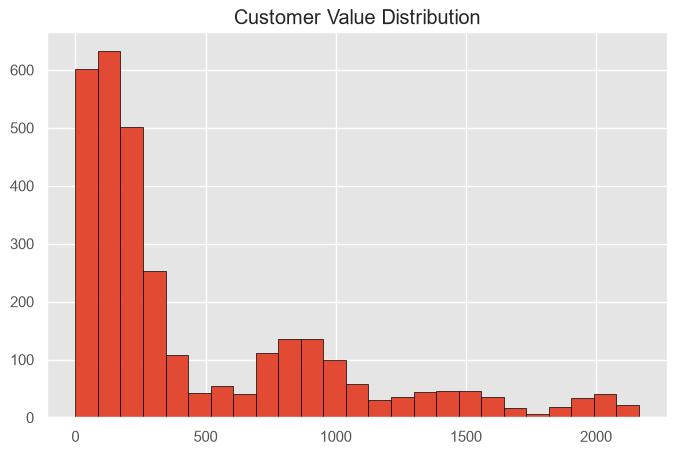

In [136]:
# Customer Value

plt.figure(figsize=(8,5))

plt.hist(
    df["Customer Value"],
    bins=25,
    edgecolor="black"
)

plt.title("Customer Value Distribution")

plt.show()

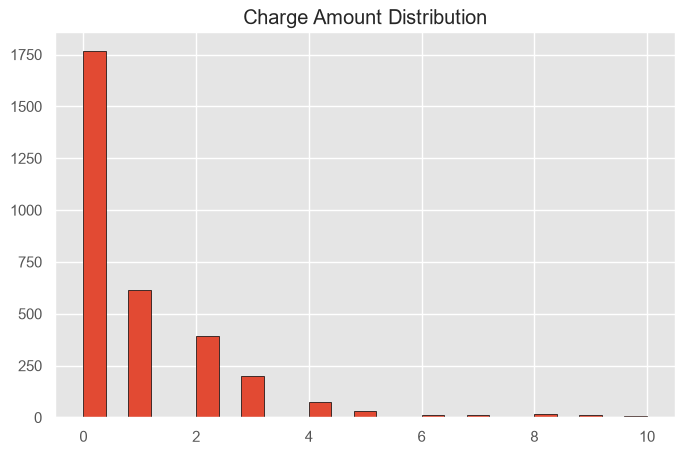

In [137]:
# Charge Amount

plt.figure(figsize=(8,5))

plt.hist(
    df["Charge  Amount"],
    bins=25,
    edgecolor="black"
)

plt.title("Charge Amount Distribution")

plt.show()

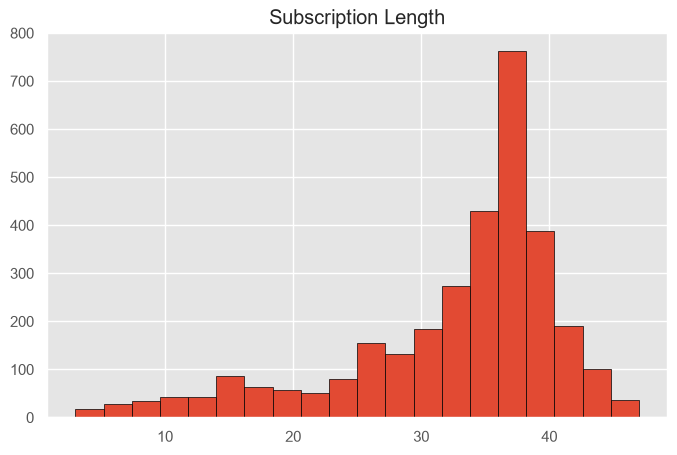

In [138]:
# Subscription Length

plt.figure(figsize=(8,5))

plt.hist(
    df["Subscription  Length"],
    bins=20,
    edgecolor="black"
)

plt.title("Subscription Length")

plt.show()

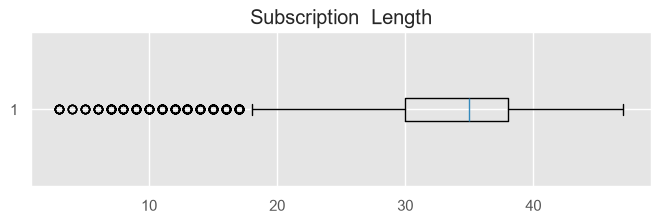

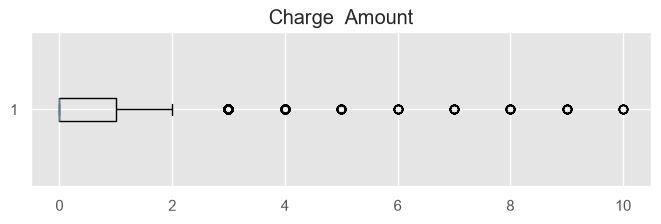

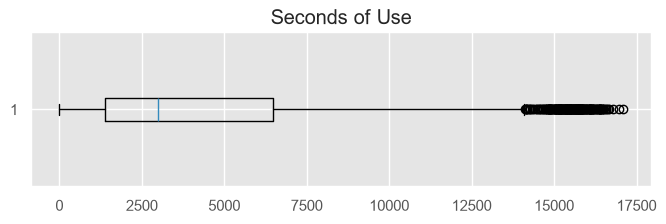

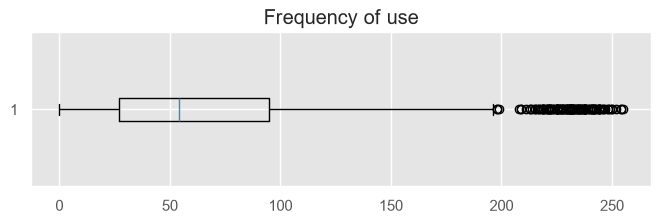

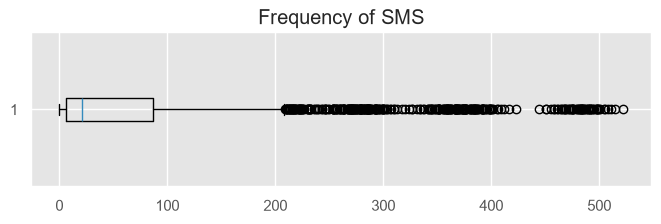

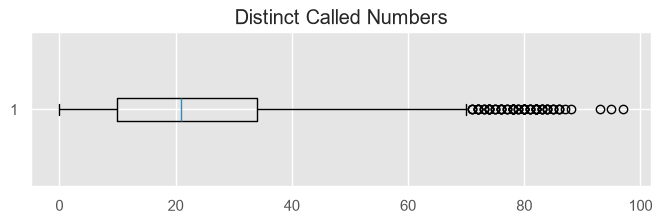

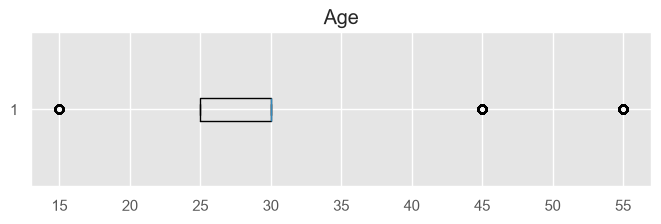

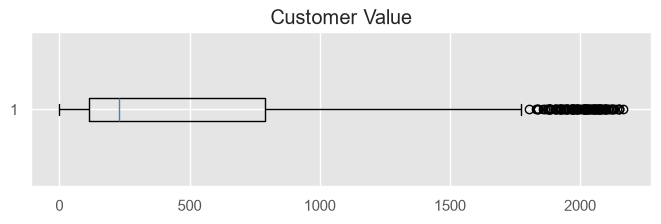

In [139]:
# Boxplots

numerical_columns = [
    "Subscription  Length",
    "Charge  Amount",
    "Seconds of Use",
    "Frequency of use",
    "Frequency of SMS",
    "Distinct Called Numbers",
    "Age",
    "Customer Value"
]

for col in numerical_columns:

    plt.figure(figsize=(8,2))

    plt.boxplot(df[col],vert=False)

    plt.title(col)

    plt.show()

Age Distribution

Observation:

- Most customers are around 25–35 years old.
- Very few customers are below 20 or above 50.

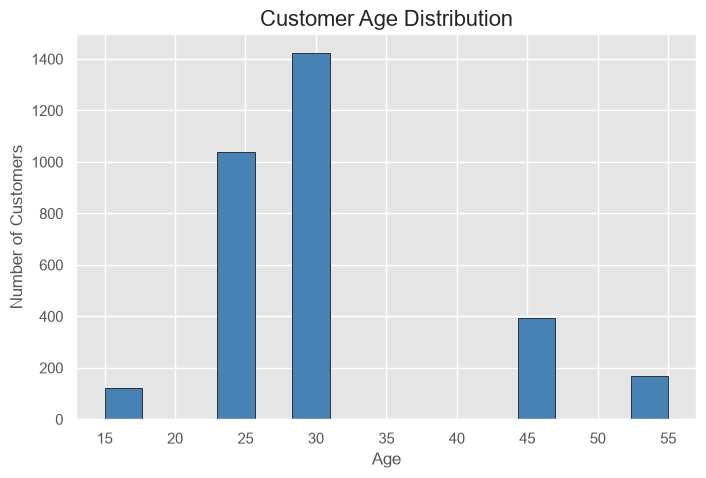

In [140]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=15,
    edgecolor="black",
    color="steelblue"
)

plt.title("Customer Age Distribution", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

Most customers belong to the **25–35 years** age group, indicating that the telecom company's primary customer base consists of young adults. Marketing and retention campaigns should primarily target this segment.

Customer Value Distribution

Observation

The distribution is highly right-skewed.

Most customers have

- Low customer value

Very few customers generate

- Extremely high revenue

This is a classic business scenario.

Business Insight

Customer Value is highly skewed. Most customers contribute relatively low revenue, while a small number of premium customers generate significantly higher value.

Retaining these high-value customers should be a top business priority.

Charge Amount Distribution

Observation

Most customers pay

- ₹0–₹2 (dataset units)

Very few customers pay higher charges.

Business Insight

The majority of customers fall into lower charge brackets, while only a small percentage contribute higher charges. Pricing strategies and premium plans should be evaluated to improve revenue without increasing churn.

Subscription Length

Observation

Most customers stay

35–40 months.

Business Insight

Most customers have remained subscribed for more than three years, suggesting a relatively loyal customer base. However, identifying the characteristics of customers with shorter subscriptions could help reduce early churn.

Boxplot

Notice

Lots of outliers.

Don't remove them.

These could be

Premium customers.

We'll keep them.

### Customer Value Distribution

#### Observation

Customer Value is positively skewed.

#### Business Insight

Premium customers contribute disproportionately to revenue.

#### Recommendation

Develop loyalty programs specifically targeting high-value customers.

### Business Question 1

Do customers who complain have a higher probability of churning?

 Churn vs Complaints

In [143]:
complaints = (
    pd.crosstab(df["Complains"], df["Churn"], normalize="index") * 100
)

complaints

Churn,0,1
Complains,,
0,89.859058,10.140942
1,17.012448,82.987552


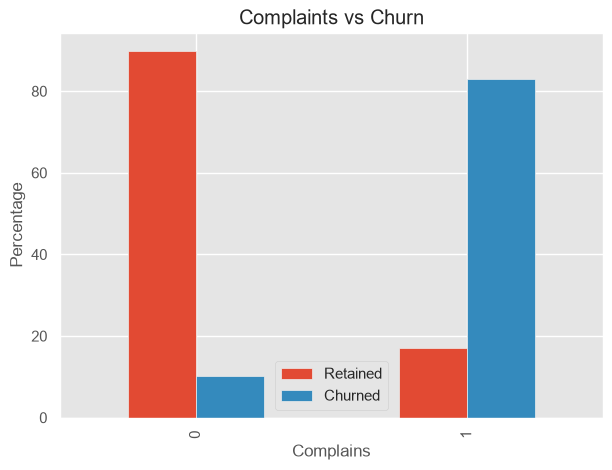

In [144]:
complaints.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Complaints vs Churn")

plt.ylabel("Percentage")

plt.legend(["Retained","Churned"])

plt.show()

Observation

Customers who registered complaints have a noticeably higher churn percentage than customers who did not complain.

Business Insight

Complaint handling appears to be a major factor influencing customer retention.

Recommendation

Improve complaint resolution time and customer support quality to reduce churn.

### Business Question 2

Which age group is most likely to churn?

Churn vs Age Group

In [145]:
age = (
    pd.crosstab(df["Age Group"], df["Churn"], normalize="index") * 100
)

age

Churn,0,1
Age Group,,
1,100.000000,0.000000
2,82.256509,17.743491
3,83.859649,16.140351
4,80.000000,20.000000
5,98.823529,1.176471


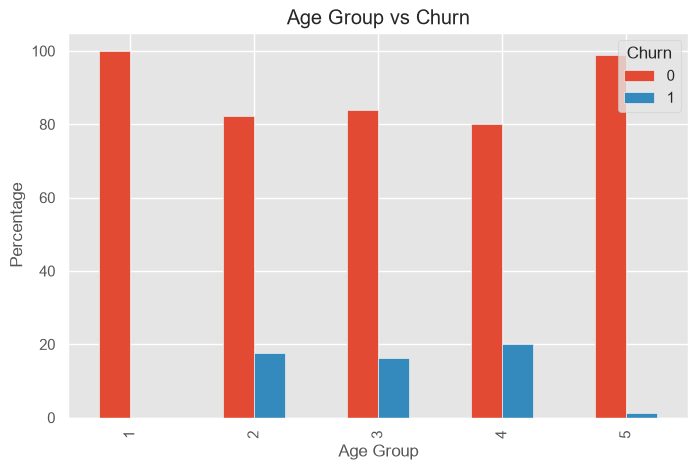

In [146]:
age.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Age Group vs Churn")

plt.ylabel("Percentage")

plt.show()

Observation

- Age Group 4 has the highest churn rate (around 20%).
- Age Groups 2 and 3 also show relatively high churn (~16–18%).
- Age Groups 1 and 5 have the lowest churn rates.

Business Insight

Customer churn varies across age groups, indicating that customer needs and engagement differ by age segment. Middle-aged customers (especially Age Group 4) appear more likely to leave the service.

Recommendation

Design targeted retention campaigns and personalized plans for Age Group 4, including loyalty rewards and customized service offerings.

### Business Question 3

Does the tariff plan influence churn?

Churn vs Tariff Plan

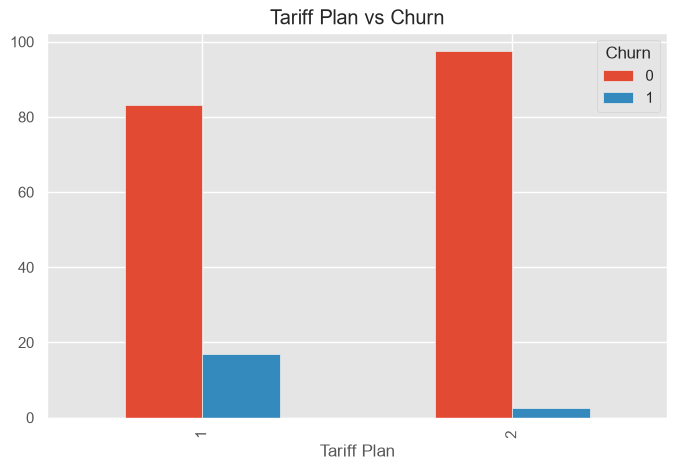

In [147]:
tariff = (
    pd.crosstab(df["Tariff Plan"], df["Churn"], normalize="index") * 100
)

tariff.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Tariff Plan vs Churn")

plt.show()

Observation

- Tariff Plan 1 has a significantly higher churn rate (~17%) compared to Tariff Plan 2 (~3%).


Business Insight

- The pricing structure or benefits of Tariff Plan 1 may not meet customer expectations, making it a major  
    contributor to customer attrition.

Recommendation

Review Tariff Plan 1 by evaluating:

    - Pricing competitiveness
    - Included services
    - Customer feedback
    - Additional benefits

Consider redesigning the plan or offering upgrade incentives.

### Business Question 4

Does customer status influence churn?

Churn vs Status

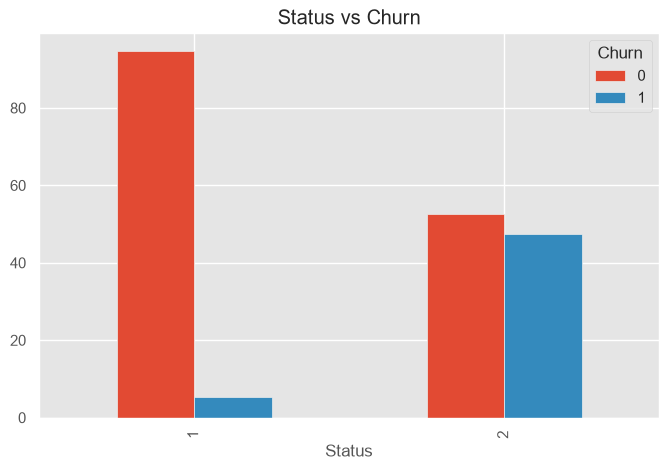

In [148]:
status = (
    pd.crosstab(df["Status"], df["Churn"], normalize="index") * 100
)

status.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Status vs Churn")

plt.show()

Observation

- Customers with Status = 2 exhibit an extremely high churn rate (almost 48%).
- Customers with Status = 1 rarely churn.


Business Insight

- Customer Status is one of the strongest indicators of churn and can be used to identify high-risk customers for   
    proactive retention efforts.

Recommendation

- Implement an early warning system that monitors customers transitioning into Status 2, allowing customer support 
    teams to intervene before churn occurs.

### Business Question 5

Do high-value customers churn?

Customer Value vs Churn

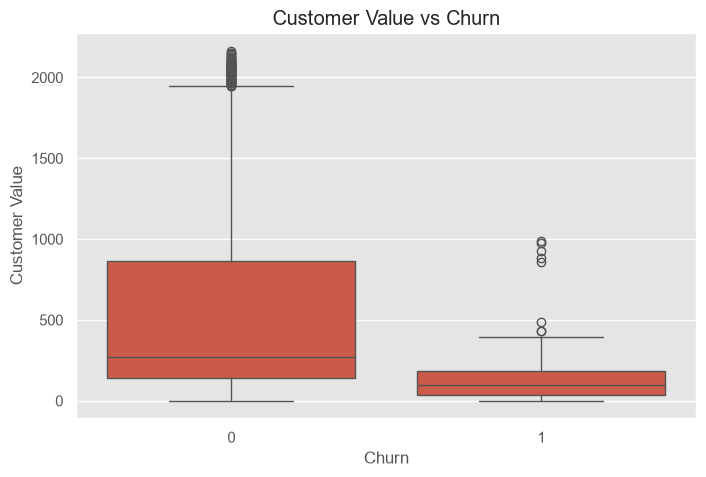

In [149]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Customer Value"
)

plt.title("Customer Value vs Churn")

plt.show()

Observation

- Customers who churn generally have much lower customer value than retained customers.
- Retained customers show a broader range of customer values, including many premium customers.


Business Insight

- High-value customers tend to remain loyal, while low-value customers are more likely to leave. This suggests that 
    customer engagement and perceived value contribute significantly to retention.

Recommendation

Increase customer value through:

- Loyalty rewards
- Personalized recommendations
- Cross-selling and upselling
- Engagement campaigns

### Business Question 6

Does subscription length affect churn?

Subscription Length vs Churn

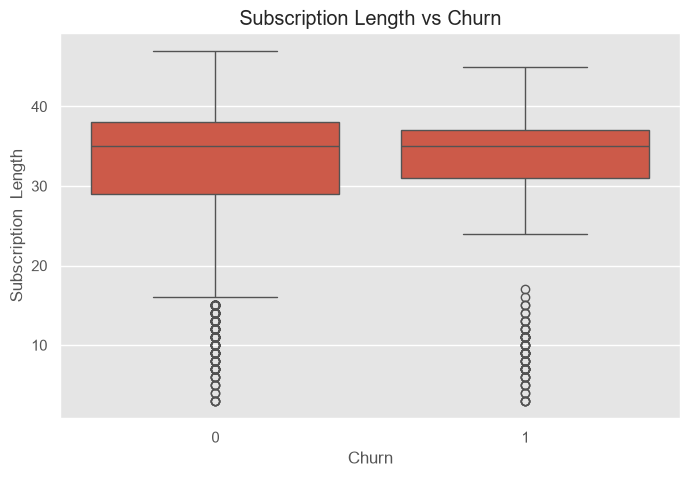

In [150]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Subscription  Length"
)

plt.title("Subscription Length vs Churn")

plt.show()

Observation

- Subscription length is very similar for churned and retained customers.
- There is no significant visual difference between the two groups.


Business Insight

- Subscription length alone does not appear to be a strong predictor of churn in this dataset. Other behavioral and 
    service-related variables likely have a greater impact.

Recommendation

- Focus retention strategies on behavioral metrics such as complaints, usage frequency, and customer status rather  
    than relying solely on subscription duration.

### Business Question 7

Which features have the strongest relationship with churn?

Correlation Heatmap

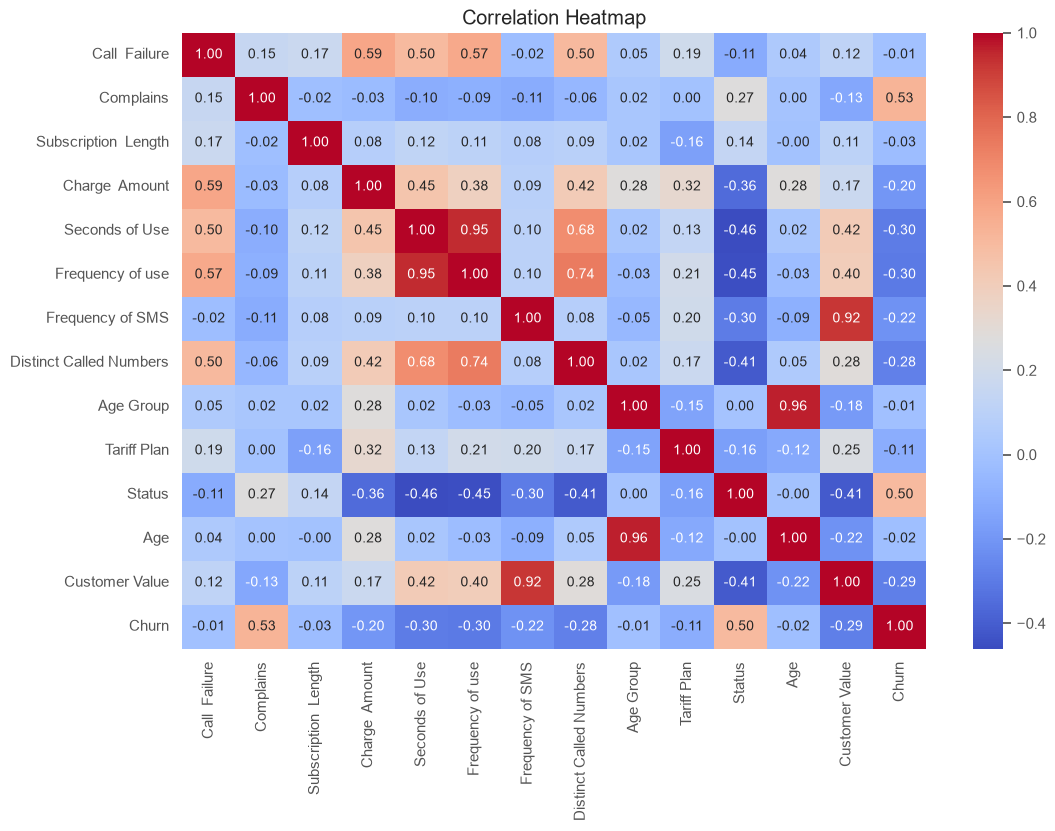

In [151]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Observation

- Strong Positive Correlations
- Feature	Correlation
- Complains	0.53
- Status	0.50

These features increase the likelihood of churn.

- Strong Negative Correlations
- Feature	Correlation
- Frequency of Use	-0.30
- Seconds of Use	-0.30
- Customer Value	-0.29
- Distinct Called Numbers	-0.28
- Frequency of SMS	-0.22
- Charge Amount	-0.20

These features are associated with lower churn.

Business Insight

- Customer behavior is a stronger indicator of churn than demographic information. Customers who use the service 
    more frequently, spend more, and engage more are less likely to churn. Conversely, complaints and customer status are the strongest warning signs.

Recommendation

Develop a churn monitoring dashboard that tracks:

- Complaint history
- Customer status
- Usage frequency
- Customer value

These indicators can be used to identify at-risk customers and trigger proactive retention campaigns.

### Top Correlated Features

In [152]:
target_corr = (
    corr["Churn"]
    .drop("Churn")
    .sort_values(ascending=False)
)

target_corr

Complains                  0.532053
Status                     0.498976
Call  Failure             -0.008987
Age Group                 -0.014550
Age                       -0.017705
Subscription  Length      -0.032588
Tariff Plan               -0.105853
Charge  Amount            -0.202305
Frequency of SMS          -0.220754
Distinct Called Numbers   -0.278867
Customer Value            -0.289144
Seconds of Use            -0.298935
Frequency of use          -0.303337
Name: Churn, dtype: float64

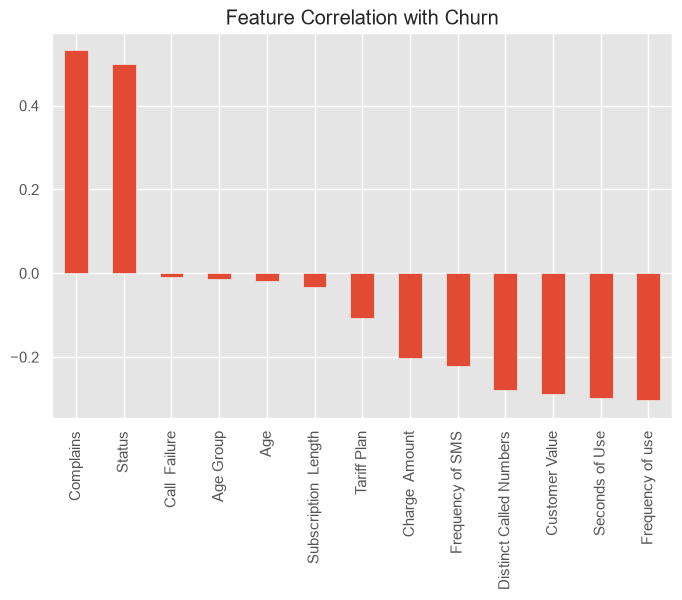

In [153]:
plt.figure(figsize=(8,5))

target_corr.plot(kind="bar")

plt.title("Feature Correlation with Churn")

plt.show()

# Executive Summary

## Project Overview

This analysis examined customer behavior for 3,150 telecom customers to identify the primary factors influencing customer churn and provide actionable recommendations for improving customer retention.

## Key Findings

1. Approximately **15.71%** of customers have churned, while **84.29%** remain active.

2. Customers with complaints are significantly more likely to churn, making complaint history the strongest predictor of customer attrition.

3. Customer Status is highly associated with churn, with Status 2 customers exhibiting the highest churn probability.

4. Tariff Plan 1 experiences substantially higher churn compared to Tariff Plan 2, indicating opportunities for pricing or service improvements.

5. Higher customer engagement, measured through call frequency, usage duration, SMS activity, and customer value, is associated with lower churn.

6. Customer Value shows a negative relationship with churn, suggesting that premium customers are generally more loyal.

7. Subscription Length has only a weak relationship with churn, indicating that behavioral metrics are more informative than customer tenure.

## Business Recommendations

- Improve complaint resolution processes and reduce response times.
- Monitor customers with Status 2 and implement proactive retention strategies.
- Redesign or optimize Tariff Plan 1.
- Launch targeted retention campaigns for low-engagement customers.
- Increase customer value through loyalty programs and personalized offers.
- Build an automated churn monitoring dashboard using the identified key risk indicators.